# Experimenting with Langgraph for Orchestration

In [20]:
from dotenv import load_dotenv
load_dotenv("../../.env")

import openai
import pandas as pd

from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, RrfQuery, Rrf

from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

In [21]:
class State(BaseModel):
    message: str 
    answer: str = ""
    vibe: str

In [22]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": f"{state.message} {state.vibe}"
    }

In [23]:
workflow = StateGraph(State)

# nodes
workflow.add_node("append_vibes_to_query", append_vibes_to_query)

# Edges
workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()


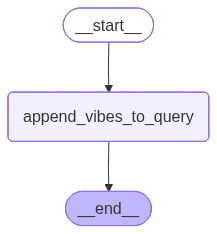

In [24]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

### Testing the demo graph

In [ ]:
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling great today",
}

In [26]:
result = graph.invoke(initial_state)

In [27]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling great today",
 'vibe': "I'm feeling great today"}

### Example conditional Graph

In [35]:
def vibe1(state: State): return {"answer": f"{state.message} Feel like watching football!"}
def vibe2(state: State): return {"answer": f"{state.message} Feel like going to sleep!"}
def vibe3(state: State): return {"answer": f"{state.message} Feel tired today!"}

In [36]:
import random

def router(state: State):
    vibes = ["vibe1", "vibe2", "vibe3"]
    return random.choice(vibes)

In [37]:
workflow = StateGraph(State)

# nodes
workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("vibe1", vibe1)
workflow.add_node("vibe2", vibe2)
workflow.add_node("vibe3", vibe3)


# Edges
workflow.add_edge(START, "append_vibes_to_query")

workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "vibe1": "vibe1",
        "vibe2": "vibe2",
        "vibe3": "vibe3",
    }
)

workflow.add_edge("vibe1", END)
workflow.add_edge("vibe2", END)
workflow.add_edge("vibe3", END)

graph = workflow.compile()

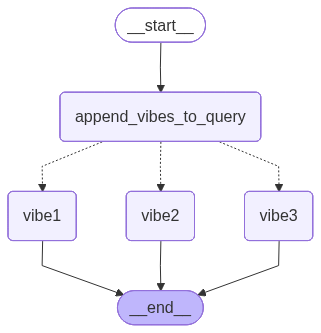

In [38]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

In [39]:
initial_state = {
    "message": "I'm the root.",
    "vibe": ""
}

graph.invoke(initial_state)

{'message': "I'm the root.",
 'answer': "I'm the root. Feel like going to sleep!",
 'vibe': ''}

In [41]:
graph.invoke(initial_state)

{'message': "I'm the root.",
 'answer': "I'm the root. Feel like watching football!",
 'vibe': ''}